<a href="https://colab.research.google.com/github/Dhanushiya-tech/Portfolio-sample/blob/main/AI_Capstone_Project_with_Deep_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import cv2
import matplotlib.pyplot as plt

In [18]:
import tarfile
import os

tar_file_path = './images_dataSAT (1).tar'
extract_dir = '.'

if os.path.exists(tar_file_path):
    print(f"Extracting {tar_file_path}...")
    with tarfile.open(tar_file_path, 'r') as tar_ref:
        tar_ref.extractall(extract_dir, filter='data') # Added filter='data' to address DeprecationWarning
    print("Extraction complete.")
else:
    print(f"Warning: {tar_file_path} not found. Please ensure the dataset is uploaded and named correctly, or adjust the path.")

Extracting ./images_dataSAT (1).tar...
Extraction complete.


In [16]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))


Saving images_dataSAT.tar to images_dataSAT (1).tar
User uploaded file "images_dataSAT (1).tar" with length 20243456 bytes


In [19]:
# Path to one sample image
sample_image_path = './images_dataSAT/class_0_non_agri/' + os.listdir('./images_dataSAT/class_0_non_agri/')[0]

# Read image
image_data = cv2.imread(sample_image_path)

# Print shape
print("Image Shape:", image_data.shape)

Image Shape: (64, 64, 3)


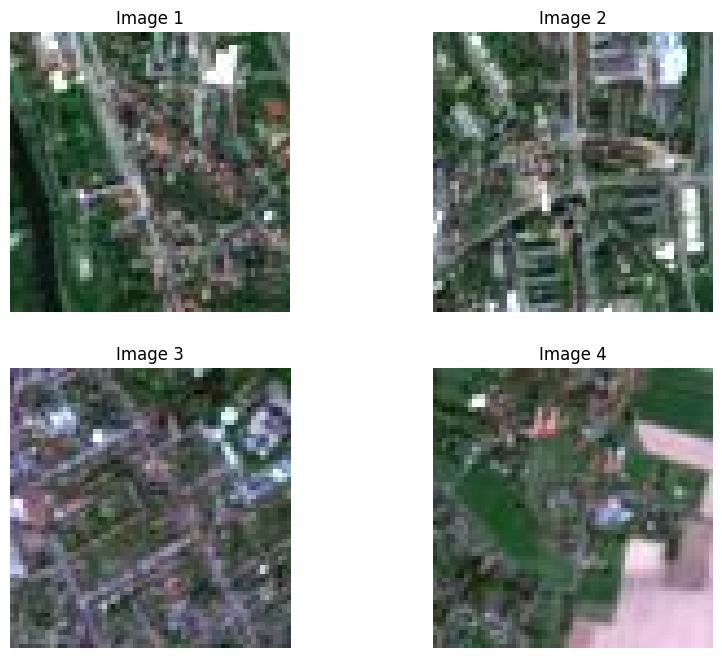

In [20]:
non_agri_dir = './images_dataSAT/class_0_non_agri/'
image_files = os.listdir(non_agri_dir)

plt.figure(figsize=(10, 8))

for i in range(4):
    img_path = os.path.join(non_agri_dir, image_files[i])
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 2, i+1)
    plt.imshow(img)
    plt.title(f"Image {i+1}")
    plt.axis('off')

plt.show()

In [21]:
dir_agri = './images_dataSAT/class_1_agri/'

agri_images_paths = [os.path.join(dir_agri, file) for file in os.listdir(dir_agri)]

# Sort the list
agri_images_paths.sort()

# Print first 5 paths (check)
print("First 5 Agri Image Paths:")
for path in agri_images_paths[:5]:
    print(path)

First 5 Agri Image Paths:
./images_dataSAT/class_1_agri/tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_5878.jpg
./images_dataSAT/class_1_agri/tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_5884.jpg
./images_dataSAT/class_1_agri/tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6628.jpg
./images_dataSAT/class_1_agri/tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6629.jpg
./images_dataSAT/class_1_agri/tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6713.jpg


In [22]:
num_agri_images = len(os.listdir(dir_agri))
print("Number of Agricultural Images:", num_agri_images)

Number of Agricultural Images: 3000


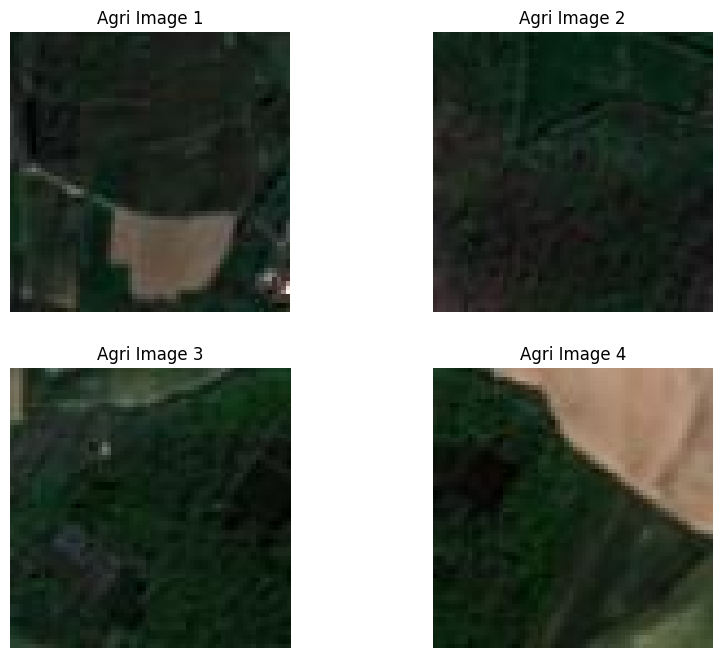

In [23]:
plt.figure(figsize=(10, 8))

for i in range(4):
    img_path = agri_images_paths[i]
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 2, i+1)
    plt.imshow(img)
    plt.title(f"Agri Image {i+1}")
    plt.axis('off')

plt.show()

In [24]:
import os
import random
import numpy as np
import cv2

In [25]:
base_dir = './images_dataSAT/'

non_agri_dir = os.path.join(base_dir, 'class_0_non_agri')
agri_dir = os.path.join(base_dir, 'class_1_agri')

# Collect image paths
non_agri_paths = [os.path.join(non_agri_dir, f) for f in os.listdir(non_agri_dir)]
agri_paths = [os.path.join(agri_dir, f) for f in os.listdir(agri_dir)]

# Combine both
all_image_paths = non_agri_paths + agri_paths

print("Total images:", len(all_image_paths))

Total images: 6000


In [26]:
# Labels: 0 → non-agri, 1 → agri
labels = [0]*len(non_agri_paths) + [1]*len(agri_paths)

# Zip paths + labels
temp = list(zip(all_image_paths, labels))

# Randomly pick 5 samples
samples = random.sample(temp, 5)

print("Random Samples:")
for path, label in samples:
    print(path, "-> Label:", label)

Random Samples:
./images_dataSAT/class_0_non_agri/tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UQB_20250427T170513.SAFE_2303.jpg -> Label: 0
./images_dataSAT/class_0_non_agri/tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UQB_20250427T170513.SAFE_17473.jpg -> Label: 0
./images_dataSAT/class_1_agri/tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UPE_20250427T170513.SAFE_11827.jpg -> Label: 1
./images_dataSAT/class_1_agri/tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UQB_20250427T170513.SAFE_9620.jpg -> Label: 1
./images_dataSAT/class_0_non_agri/tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UQB_20250427T170513.SAFE_2458.jpg -> Label: 0


In [27]:
def custom_data_generator(image_paths, labels, batch_size=8):
    while True:
        for i in range(0, len(image_paths), batch_size):
            batch_paths = image_paths[i:i+batch_size]
            batch_labels = labels[i:i+batch_size]

            images = []

            for path in batch_paths:
                img = cv2.imread(path)
                img = cv2.resize(img, (64, 64))
                img = img / 255.0
                images.append(img)

            yield np.array(images), np.array(batch_labels)

In [28]:
generator = custom_data_generator(all_image_paths, labels, batch_size=8)

X_batch, y_batch = next(generator)

print("Batch images shape:", X_batch.shape)
print("Batch labels shape:", y_batch.shape)

Batch images shape: (8, 64, 64, 3)
Batch labels shape: (8,)


In [29]:
# Split into train & validation
split = int(0.8 * len(all_image_paths))

train_paths = all_image_paths[:split]
train_labels = labels[:split]

val_paths = all_image_paths[split:]
val_labels = labels[split:]

# Validation generator
val_generator = custom_data_generator(val_paths, val_labels, batch_size=8)

# Get validation batch
X_val, y_val = next(val_generator)

print("Validation batch shape:", X_val.shape)
print("Validation labels shape:", y_val.shape)

Validation batch shape: (8, 64, 64, 3)
Validation labels shape: (8,)


In [30]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

In [31]:
custom_transform = transforms.Compose([
    transforms.Resize((64, 64)),                 # 1. Resize
    transforms.RandomHorizontalFlip(p=0.5),      # 2. Horizontal flip
    transforms.RandomVerticalFlip(p=0.2),        # 3. Vertical flip
    transforms.RandomRotation(45),               # 4. Rotation
    transforms.ToTensor()                        # Convert to tensor
])

In [32]:
dataset_path = './images_dataSAT/'  # main folder containing both classes

imagefolder_dataset = datasets.ImageFolder(
    root=dataset_path,
    transform=custom_transform
)

In [33]:
print("Class to Index Mapping:")
print(imagefolder_dataset.class_to_idx)

Class to Index Mapping:
{'class_0_non_agri': 0, 'class_1_agri': 1}


In [34]:
imagefolder_loader = DataLoader(
    imagefolder_dataset,
    batch_size=8,
    shuffle=True
)

In [35]:
# Get one batch
images, labels = next(iter(imagefolder_loader))

print("Image Batch Shape:", images.shape)
print("Label Batch Shape:", labels.shape)

Image Batch Shape: torch.Size([8, 3, 64, 64])
Label Batch Shape: torch.Size([8])


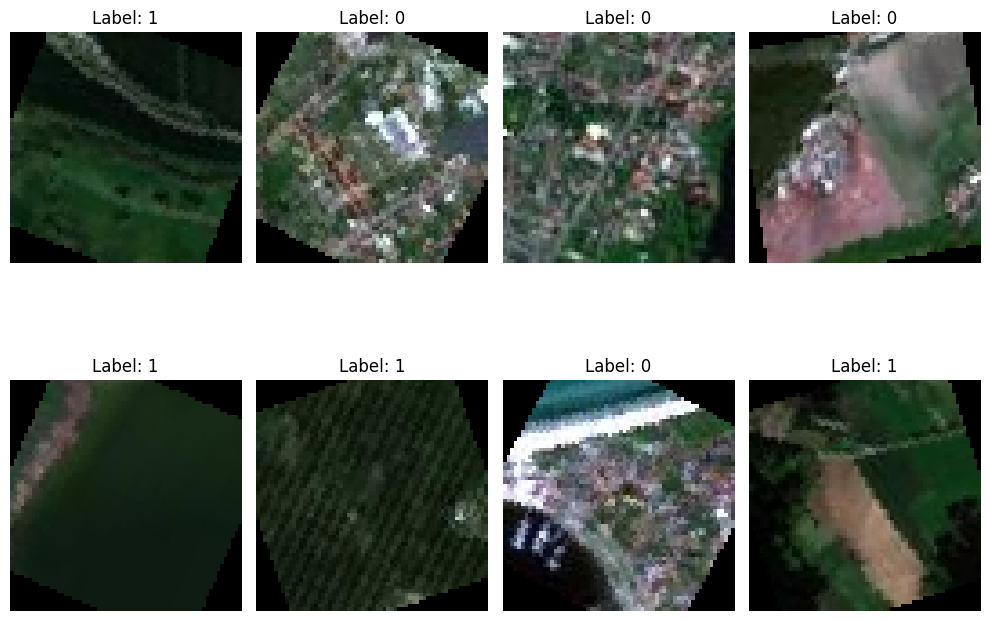

In [36]:
plt.figure(figsize=(10, 8))

for i in range(8):
    img = images[i].numpy().transpose((1, 2, 0))  # Convert CHW → HWC

    plt.subplot(2, 4, i+1)
    plt.imshow(img)
    plt.title(f"Label: {labels[i].item()}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [37]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint
import matplotlib.pyplot as plt

In [38]:
dataset_path = './images_dataSAT/'

fnames = []

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.endswith(('.jpg', '.png', '.jpeg')):
            fnames.append(os.path.join(root, file))

print("Total image files:", len(fnames))
print("Sample files:", fnames[:5])

Total image files: 6000
Sample files: ['./images_dataSAT/class_1_agri/tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UQB_20250427T170513.SAFE_5280.jpg', './images_dataSAT/class_1_agri/tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UQB_20250427T170513.SAFE_15868.jpg', './images_dataSAT/class_1_agri/tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UPE_20250427T170513.SAFE_9521.jpg', './images_dataSAT/class_1_agri/tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UQB_20250427T170513.SAFE_18759.jpg', './images_dataSAT/class_1_agri/tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UQB_20250427T170513.SAFE_8871.jpg']


In [39]:
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

validation_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(64, 64),
    batch_size=8,
    class_mode='binary',
    subset='validation'
)

Found 1200 images belonging to 2 classes.


In [40]:
train_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(64, 64),
    batch_size=8,
    class_mode='binary',
    subset='training'
)

Found 4800 images belonging to 2 classes.


In [41]:
test_model = models.Sequential()

# 4 Conv2D layers
test_model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)))
test_model.add(layers.MaxPooling2D((2,2)))

test_model.add(layers.Conv2D(64, (3,3), activation='relu'))
test_model.add(layers.MaxPooling2D((2,2)))

test_model.add(layers.Conv2D(128, (3,3), activation='relu'))
test_model.add(layers.MaxPooling2D((2,2)))

test_model.add(layers.Conv2D(128, (3,3), activation='relu'))
test_model.add(layers.MaxPooling2D((2,2)))

test_model.add(layers.Flatten())

# 5 Dense layers
test_model.add(layers.Dense(128, activation='relu'))
test_model.add(layers.Dense(64, activation='relu'))
test_model.add(layers.Dense(32, activation='relu'))
test_model.add(layers.Dense(16, activation='relu'))
test_model.add(layers.Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [42]:
print("Total number of layers:", len(test_model.layers))

Total number of layers: 14


In [43]:
test_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [44]:
checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

In [45]:
history = test_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=5,
    callbacks=[checkpoint]
)

Epoch 1/5
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.8834 - loss: 0.2447
Epoch 1: val_accuracy improved from None to 0.98667, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
600/600 ━━━━━━━━━━━━━━━━━━━━ 47s 73ms/step - accuracy: 0.9510 - loss: 0.1263 - val_accuracy: 0.9867 - val_loss: 0.0383
Epoch 2/5
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.9726 - loss: 0.0839
Epoch 2: val_accuracy did not improve from 0.98667
600/600 ━━━━━━━━━━━━━━━━━━━━ 45s 75ms/step - accuracy: 0.9715 - loss: 0.0804 - val_accuracy: 0.9300 - val_loss: 0.1248
Epoch 3/5
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.9622 - loss: 0.1168
Epoch 3: val_accuracy did not improve from 0.98667
600/600 ━━━━━━━━━━━━━━━━━━━━ 43s 72ms/step - accuracy: 0.9735 - loss: 0.0823 - val_accuracy: 0.9858 - val_loss: 0.0700
Epoch 4/5
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.9811 - loss: 0.0498
Epoch 4: val_accuracy did not improve from 0.98667
600/600 ━━━━━━━━━━━━━━━━━━━━ 43s 72ms/step - accuracy: 0.9827 - loss: 0.0499 - val_accuracy: 0.9858 - val_loss: 0.0405
Epoch 5/5
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 

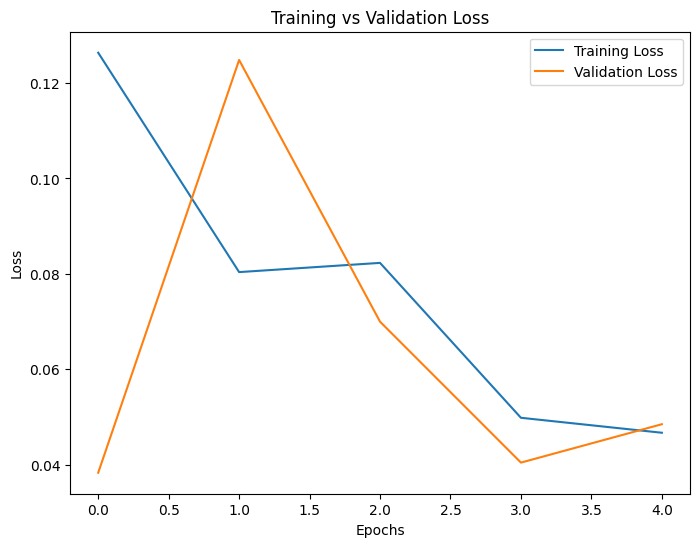

In [46]:
plt.figure(figsize=(8,6))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

Task 1: Why is random initialization useful?

Random initialization helps break symmetry in neural networks.
If all weights are initialized to the same value, neurons will learn the same features.
Random initialization ensures different neurons learn different patterns, improving model performance and convergence.

---



In [47]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm

In [48]:
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(30),
    transforms.ToTensor()
])

In [49]:
val_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

In [50]:
dataset_path = './images_dataSAT/'

train_dataset = datasets.ImageFolder(root=dataset_path, transform=train_transform)
val_dataset = datasets.ImageFolder(root=dataset_path, transform=val_transform)

In [51]:
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

In [52]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*14*14, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

In [53]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SimpleCNN().to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

Task 5: What is tqdm?

tqdm is used to display a progress bar during training or iteration loops.
It helps track progress, speed, and estimated time remaining.

Task 6: Why reset loss/counters?

train_loss, train_correct, and train_total are reset every epoch to measure performance per epoch.
Without resetting, values would accumulate across epochs and give incorrect metrics.

Task 7: Why torch.no_grad()?

torch.no_grad() disables gradient computation during validation.
This reduces memory usage and speeds up computation since gradients are not needed.

Task 8: Two evaluation metrics

Two metrics:
1. Accuracy
2. Loss

In [54]:
num_epochs = 5
train_losses = []

for epoch in range(num_epochs):
    model.train()

    running_loss = 0.0

    for images, labels in tqdm(train_loader):
        images, labels = images.to(device), labels.to(device).float().unsqueeze(1)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)

    print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}")

100%|██████████| 750/750 [00:49<00:00, 15.09it/s]


Epoch 1, Loss: 0.0917


100%|██████████| 750/750 [00:52<00:00, 14.16it/s]


Epoch 2, Loss: 0.0607


100%|██████████| 750/750 [00:53<00:00, 14.01it/s]


Epoch 3, Loss: 0.0519


100%|██████████| 750/750 [00:53<00:00, 14.11it/s]


Epoch 4, Loss: 0.0386


100%|██████████| 750/750 [00:53<00:00, 14.02it/s]

Epoch 5, Loss: 0.0367


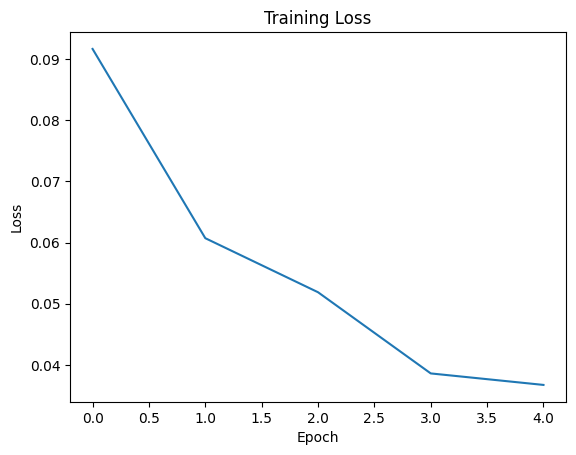

In [55]:
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [56]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)

        outputs = model(images)
        preds = (outputs > 0.5).float()

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print("Predictions sample:", all_preds[:10])
print("Labels sample:", all_labels[:10])

Predictions sample: [array([0.], dtype=float32), array([0.], dtype=float32), array([0.], dtype=float32), array([0.], dtype=float32), array([0.], dtype=float32), array([0.], dtype=float32), array([0.], dtype=float32), array([0.], dtype=float32), array([0.], dtype=float32), array([0.], dtype=float32)]
Labels sample: [np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)]


What does preds > 0.5 do?

The expression (preds > 0.5) converts predicted probabilities into binary class labels.

If prediction > 0.5 → class 1  
If prediction ≤ 0.5 → class 0  

.astype(int) converts True/False into 1/0  
.flatten() converts the array into 1D format

In [58]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [59]:
def print_metrics(y_true, y_pred, model_name="Model"):
    print(f"\n📊 {model_name} Performance:")

    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1 Score :", f1_score(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred)
    print("\nConfusion Matrix:\n", cm)

    return cm

In [61]:
# Make predictions using the trained Keras model
keras_preds = test_model.predict(X_val)

# Convert probabilities → binary
keras_preds = (keras_preds > 0.5).astype(int).flatten()

# Ground truth labels (from your custom generator validation batch)
y_true = y_val

# Print metrics
cm_keras = print_metrics(y_true, keras_preds, "Keras Model")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step

📊 Keras Model Performance:
Accuracy : 0.875
Precision: 1.0
Recall   : 0.875
F1 Score : 0.9333333333333333

Confusion Matrix:
 [[0 0]
 [1 7]]


Task 3: What is F1 Score?

F1 Score is the harmonic mean of Precision and Recall.
It balances both false positives and false negatives.
It is especially useful when the dataset is imbalanced.

Formula:
F1 = 2 * (Precision * Recall) / (Precision + Recall)

In [62]:
# Convert predictions list → numpy
torch_preds = np.array(all_preds).flatten()
torch_labels = np.array(all_labels).flatten()

# Ensure binary format
torch_preds = (torch_preds > 0.5).astype(int)

# Print metrics
cm_torch = print_metrics(torch_labels, torch_preds, "PyTorch Model")


📊 PyTorch Model Performance:
Accuracy : 0.9915
Precision: 0.9836011807149885
Recall   : 0.9996666666666667
F1 Score : 0.9915688543560919

Confusion Matrix:
 [[2950   50]
 [   1 2999]]


In [63]:
# Confusion matrix format:
# [[TN, FP],
#  [FN, TP]]

false_negatives = cm_torch[1][0]

print("False Negatives:", false_negatives)

False Negatives: 1


In [64]:
import tensorflow as tf
from tensorflow.keras.models import load_model

In [65]:
# Load your saved CNN model
cnn_model = load_model('best_model.h5')

# Print summary
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 317,379 (1.21 MB)

 Trainable params: 317,377 (1.21 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [66]:
# Example (replace if your layer name is different)
feature_layer_name = cnn_model.layers[-3].name

print("Feature Extraction Layer:", feature_layer_name)

Feature Extraction Layer: dense_2


In [70]:
from tensorflow.keras import layers, models
import tensorflow as tf # Ensure tf is imported for tf.expand_dims

# Custom layer to wrap tf.expand_dims
class ExpandDimsLayer(layers.Layer):
    def __init__(self, axis, **kwargs):
        super().__init__(**kwargs)
        self.axis = axis

    def call(self, inputs):
        return tf.expand_dims(inputs, axis=self.axis)

    def get_config(self):
        config = super().get_config()
        config.update({"axis": self.axis})
        return config

def build_cnn_vit_hybrid(cnn_model, feature_layer_name):
    # Define an explicit Input layer for the new hybrid model
    hybrid_input = tf.keras.Input(shape=(64, 64, 3))
    x = hybrid_input

    # Apply layers of the cnn_model sequentially until the feature layer
    for layer in cnn_model.layers:
        x = layer(x)
        # If this is our target feature layer, we use its output and break
        if layer.name == feature_layer_name:
            break

    feature_output = x

    # Reshape for Transformer: (batch_size, features) -> (batch_size, 1, features)
    # Use the custom layer for tf.expand_dims
    x = ExpandDimsLayer(axis=1)(feature_output) # Shape becomes (None, 1, embedding_dim)

    # Transformer Encoder Block
    # key_dim should match the embedding_dim (x.shape[-1])
    attention = layers.MultiHeadAttention(num_heads=4, key_dim=x.shape[-1])(x, x)
    x = layers.Add()([x, attention])
    x = layers.LayerNormalization()(x)

    x_ff = layers.Dense(128, activation='relu')(x)
    x_ff = layers.Dense(x.shape[-1])(x_ff) # Output dimension matches input for residual
    x = layers.Add()([x, x_ff])
    x = layers.LayerNormalization()(x)

    # Global pooling (from (None, 1, embedding_dim) to (None, embedding_dim))
    x = layers.GlobalAveragePooling1D()(x)

    # Final classification
    output = layers.Dense(1, activation='sigmoid')(x)

    hybrid_model = models.Model(inputs=hybrid_input, outputs=output)

    return hybrid_model

# The cnn_model should already be built/have input shape defined after loading from .h5
# If not, you might need to build it with a dummy input or cnn_model.build((None, 64, 64, 3))
# However, for using its layers in a functional API construction, explicit input is more reliable.

# Create model
hybrid_model = build_cnn_vit_hybrid(cnn_model, feature_layer_name)

# Show summary
hybrid_model.summary()

Model: "functional_29"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 62, 62,    │        896 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 31, 31,    │          0 │ conv2d[16][0]     │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 29, 29,    │     18,496 │ max_pooling2d[15… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 14, 14,    │          0 │ conv2d_1[14][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 12, 12,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 6, 6, 128) │          0 │ conv2d_2[12][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 4, 4, 128) │    147,584 │ max_pooling2d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 2, 2, 128) │          0 │ conv2d_3[10][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 512)       │          0 │ max_pooling2d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     65,664 │ flatten[8][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ dense[7][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      2,080 │ dense_1[6][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expand_dims_layer   │ (None, 1, 32)     │          0 │ dense_2[5][0]     │
│ (ExpandDimsLayer)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 1, 32)     │     16,800 │ expand_dims_laye… │
│ (MultiHeadAttentio… │                   │            │ expand_dims_laye… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1, 32)     │          0 │ expand_dims_laye… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 1, 32)     │         64 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1, 128)    │      4,224 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 1, 32)     │      4,128 │ dense_5[0][0]   

 Total params: 342,145 (1.31 MB)

 Trainable params: 342,145 (1.31 MB)

 Non-trainable params: 0 (0.00 B)

In [71]:
hybrid_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [72]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(
    'hybrid_best_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

# Example training config
history = hybrid_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=5,
    callbacks=[checkpoint]
)

Epoch 1/5
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.9501 - loss: 0.1509
Epoch 1: val_accuracy improved from None to 0.97500, saving model to hybrid_best_model.h5



Epoch 1: finished saving model to hybrid_best_model.h5
600/600 ━━━━━━━━━━━━━━━━━━━━ 53s 77ms/step - accuracy: 0.9594 - loss: 0.1303 - val_accuracy: 0.9750 - val_loss: 0.0723
Epoch 2/5
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9813 - loss: 0.0798
Epoch 2: val_accuracy improved from 0.97500 to 0.97917, saving model to hybrid_best_model.h5



Epoch 2: finished saving model to hybrid_best_model.h5
600/600 ━━━━━━━━━━━━━━━━━━━━ 45s 75ms/step - accuracy: 0.9787 - loss: 0.0813 - val_accuracy: 0.9792 - val_loss: 0.0631
Epoch 3/5
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.9827 - loss: 0.0566
Epoch 3: val_accuracy improved from 0.97917 to 0.98750, saving model to hybrid_best_model.h5



Epoch 3: finished saving model to hybrid_best_model.h5
600/600 ━━━━━━━━━━━━━━━━━━━━ 44s 74ms/step - accuracy: 0.9777 - loss: 0.0661 - val_accuracy: 0.9875 - val_loss: 0.0457
Epoch 4/5
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.9790 - loss: 0.0672
Epoch 4: val_accuracy did not improve from 0.98750
600/600 ━━━━━━━━━━━━━━━━━━━━ 47s 78ms/step - accuracy: 0.9806 - loss: 0.0683 - val_accuracy: 0.9850 - val_loss: 0.0645
Epoch 5/5
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.9860 - loss: 0.0468
Epoch 5: val_accuracy did not improve from 0.98750
600/600 ━━━━━━━━━━━━━━━━━━━━ 44s 73ms/step - accuracy: 0.9852 - loss: 0.0510 - val_accuracy: 0.9875 - val_loss: 0.0522


In [73]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import time

In [74]:
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(30),
    transforms.ToTensor()
])

In [75]:
val_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

In [76]:
dataset_path = './images_dataSAT/'

train_dataset = datasets.ImageFolder(root=dataset_path, transform=train_transform)
val_dataset = datasets.ImageFolder(root=dataset_path, transform=val_transform)

In [77]:
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

In [78]:
class CNN_ViT(nn.Module):
    def __init__(self, embed_dim=768, num_heads=12, depth=12):
        super(CNN_ViT, self).__init__()

        # CNN feature extractor
        self.cnn = nn.Sequential(
            nn.Conv2d(3, 64, 3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Flatten and project
        self.flatten = nn.Flatten()
        self.fc_embed = nn.Linear(128*16*16, embed_dim)

        # Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=depth
        )

        # Classifier
        self.fc = nn.Linear(embed_dim, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.cnn(x)
        x = self.flatten(x)
        x = self.fc_embed(x)

        x = x.unsqueeze(1)  # add sequence dimension
        x = self.transformer(x)
        x = x.squeeze(1)

        x = self.fc(x)
        return self.sigmoid(x)

In [79]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Base model
model = CNN_ViT(embed_dim=256, num_heads=4, depth=4).to(device)

# Required model_test (as per question)
model_test = CNN_ViT(embed_dim=768, num_heads=12, depth=12).to(device)

/tmp/ipykernel_27578/3605330913.py:25: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.transformer = nn.TransformerEncoder(


In [80]:
def train_model(model, train_loader, val_loader, epochs=5):
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    val_losses = []
    start_time = time.time()

    for epoch in range(epochs):
        model.train()

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device).float().unsqueeze(1)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

        # Validation loss
        model

In [81]:
import torch
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [82]:
# Dataset path
dataset_path = './images_dataSAT/'

# Same transforms used earlier
val_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

# Dataset
val_dataset = datasets.ImageFolder(root=dataset_path, transform=val_transform)

# DataLoader
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

# Hyperparameters (same as training)
embed_dim = 768
num_heads = 12
depth = 12

In [83]:
import torch.nn as nn

class CNN_ViT(nn.Module):
    def __init__(self, embed_dim=768, num_heads=12, depth=12):
        super(CNN_ViT, self).__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.flatten = nn.Flatten()
        self.fc_embed = nn.Linear(128*16*16, embed_dim)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)

        self.fc = nn.Linear(embed_dim, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.cnn(x)
        x = self.flatten(x)
        x = self.fc_embed(x)

        x = x.unsqueeze(1)
        x = self.transformer(x)
        x = x.squeeze(1)

        x = self.fc(x)
        return self.sigmoid(x)


# Initialize model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pytorch_model = CNN_ViT(embed_dim, num_heads, depth).to(device)

/tmp/ipykernel_27578/55607282.py:24: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)


In [84]:
def print_metrics(y_true, y_pred, model_name="Model"):
    print(f"\n📊 {model_name}")

    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1 Score :", f1_score(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred)
    print("Confusion Matrix:\n", cm)

In [85]:
# Assuming you already have keras model predictions
# keras_preds = hybrid_model.predict(X_val)

# Convert to binary
keras_preds = (keras_preds > 0.5).astype(int).flatten()

# Ground truth
y_true = y_val  # replace with your actual labels

# Print metrics
print_metrics(y_true, keras_preds, "Keras CNN-ViT Hybrid Model")


📊 Keras CNN-ViT Hybrid Model
Accuracy : 0.875
Precision: 1.0
Recall   : 0.875
F1 Score : 0.9333333333333333
Confusion Matrix:
 [[0 0]
 [1 7]]


In [86]:
pytorch_model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)

        outputs = pytorch_model(images)
        preds = (outputs > 0.5).float()

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Convert to numpy
all_preds = np.array(all_preds).flatten()
all_labels = np.array(all_labels).flatten()

# Print metrics
print_metrics(all_labels, all_preds, "PyTorch CNN-ViT Hybrid Model")


📊 PyTorch CNN-ViT Hybrid Model
Accuracy : 0.5106666666666667
Precision: 0.5189349112426036
Recall   : 0.29233333333333333
F1 Score : 0.3739872068230277
Confusion Matrix:
 [[2187  813]
 [2123  877]]
